In [1]:
# Added for the public reproduction package: load the pseudonymized CSV instead of the
# private spreadsheet and write any output files to ../output/notebooks/. See repro_data.py.
import repro_data


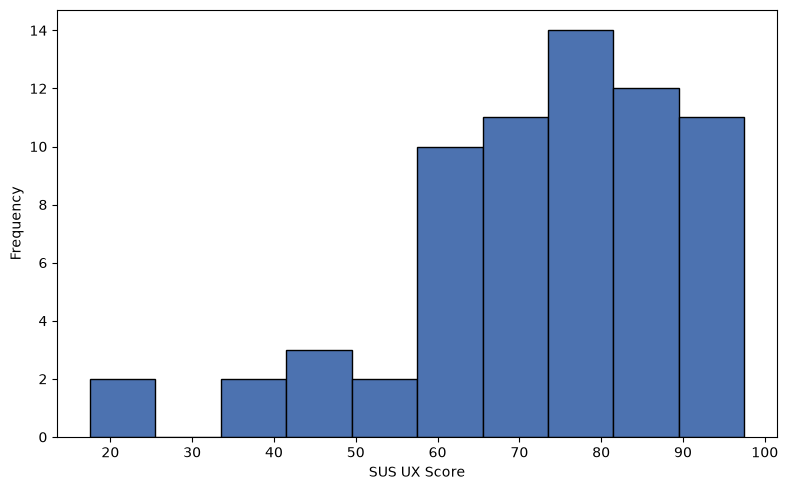

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Carga de datos ---
archivo = "Wallet-pattern-.xlsx"
hoja = "Datos cuanti"

df = repro_data.read_datos_cuanti()

# --- Histograma general de SUS UX (todos los tratamientos juntos) ---
plt.figure(figsize=(8, 5))
plt.hist(
    df["SUS UX"].dropna(),
    bins=10,
    edgecolor="black",
    color="#4C72B0"
)

plt.xlabel("SUS UX Score")
plt.ylabel("Frequency")
plt.tight_layout()

# Guardar como PDF
plt.savefig(
    "sus_ux_histograma.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

Media y DE por pregunta y tratamiento:
   Question                      Treatment  mean  std  n
 Question 1      T1 - Single auth (mobile)  3.47 0.72 17
 Question 1 T2 - Multi-sign (desktop-init)  3.18 1.19 17
 Question 1  T3 - Multi-sign (mobile-init)  3.61 0.98 18
 Question 1     T4 - Single auth (desktop)  3.80 0.94 15
 Question 2      T1 - Single auth (mobile)  2.12 1.22 17
 Question 2 T2 - Multi-sign (desktop-init)  2.82 1.51 17
 Question 2  T3 - Multi-sign (mobile-init)  2.33 1.08 18
 Question 2     T4 - Single auth (desktop)  2.13 1.46 15
 Question 3      T1 - Single auth (mobile)  4.06 0.90 17
 Question 3 T2 - Multi-sign (desktop-init)  3.65 1.11 17
 Question 3  T3 - Multi-sign (mobile-init)  3.94 0.80 18
 Question 3     T4 - Single auth (desktop)  4.27 1.03 15
 Question 4      T1 - Single auth (mobile)  2.06 1.34 17
 Question 4 T2 - Multi-sign (desktop-init)  2.06 1.25 17
 Question 4  T3 - Multi-sign (mobile-init)  2.72 1.45 18
 Question 4     T4 - Single auth (desktop)  1.93 

/var/folders/6j/_mylx7ls4nv_bm5njjz_tbl00000gn/T/ipykernel_84244/3608529455.py:77: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  ax = sns.barplot(
/var/folders/6j/_mylx7ls4nv_bm5njjz_tbl00000gn/T/ipykernel_84244/3608529455.py:77: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  ax = sns.barplot(


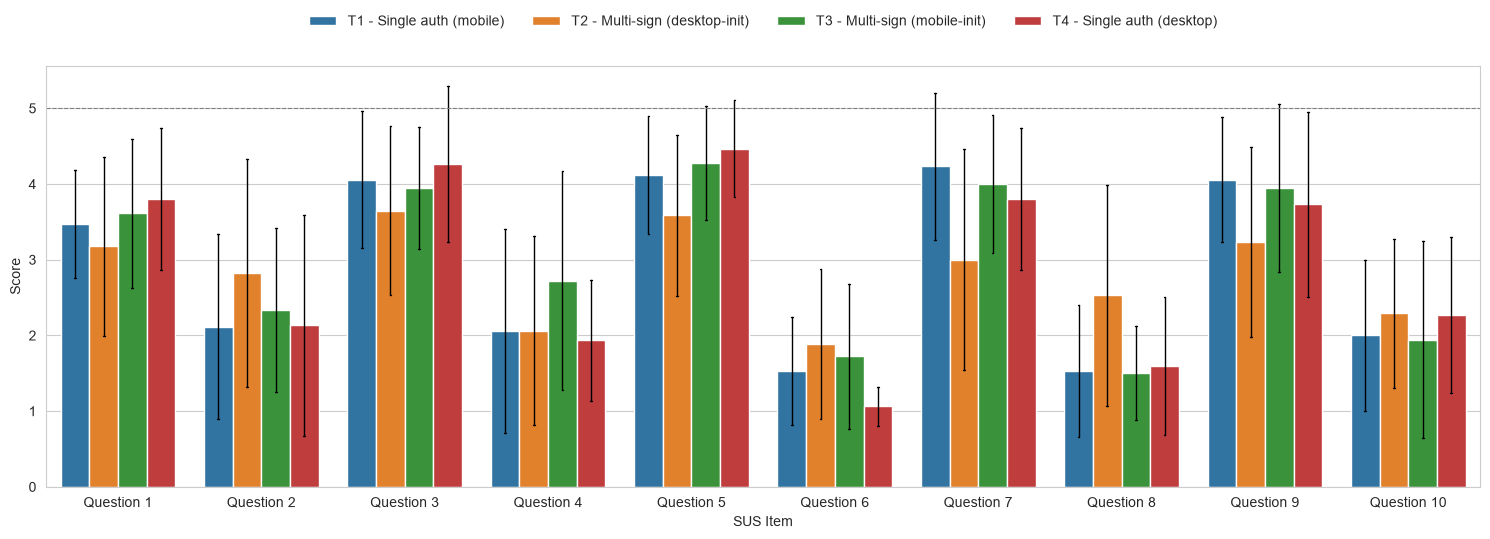

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Carga de datos ---
archivo = "Wallet-pattern-.xlsx"
hoja = "Datos cuanti"

df = repro_data.read_datos_cuanti()

# --- Columnas de las 10 preguntas del SUS (en el orden del cuestionario) ---
preguntas = [
    "Creo que me gustaría utilizar este sistema con frecuencia",
    "Encontré el sistema innecesariamente complejo",
    "Pienso que el sistema fue fácil de usar",
    "Creo que necesitaría el apoyo de una persona técnica para poder usar este sistema",
    "Descubrí que las diversas funciones de este sistema estaban bien integradas",
    "Pienso que había demasiada inconsistencia en este sistema",
    "Me imagino que la mayoría de la gente aprendería a usar este sistema muy rápidamente",
    "Encontré el sistema muy engorroso de usar",
    "Me sentí muy seguro de usar el sistema",
    "Necesité aprender muchas cosas antes de poder comenzar con este sistema",
]

# Etiquetas de tratamiento para la leyenda
etiquetas_tratamiento = {
    1: "T1 - Single auth (mobile)",
    2: "T2 - Multi-sign (desktop-init)",
    3: "T3 - Multi-sign (mobile-init)",
    4: "T4 - Single auth (desktop)",
}

# --- Pasar de formato ancho a formato largo (una fila por respuesta-pregunta) ---
df_long = df.melt(
    id_vars=["Grupo"],
    value_vars=preguntas,
    var_name="Pregunta",
    value_name="Score",
)

# Nombre corto "Question N" para el eje X, en el orden original del cuestionario
mapa_preguntas = {p: f"Question {i+1}" for i, p in enumerate(preguntas)}
df_long["Question"] = df_long["Pregunta"].map(mapa_preguntas)
df_long["Question"] = pd.Categorical(
    df_long["Question"],
    categories=[f"Question {i+1}" for i in range(len(preguntas))],
    ordered=True,
)

df_long["Treatment"] = df_long["Grupo"].map(etiquetas_tratamiento)

# --- Media y desvío estándar por pregunta y tratamiento ---
resumen = (
    df_long.groupby(["Question", "Treatment"], observed=True)["Score"]
    .agg(mean="mean", std="std", n="count")
    .round(2)
    .reset_index()
)

# Tabla en formato ancho: una fila por pregunta, columnas de media por tratamiento
resumen_medias = resumen.pivot(index="Question", columns="Treatment", values="mean")
resumen_medias = resumen_medias[[etiquetas_tratamiento[g] for g in sorted(etiquetas_tratamiento)]]

print("Media y DE por pregunta y tratamiento:")
print(resumen.to_string(index=False))

print("\nTabla de medias (pregunta x tratamiento):")
print(resumen_medias)

# Exportar a Excel para tenerlo a mano
resumen.to_excel("sus_media_de_por_pregunta.xlsx", index=False)

# --- Gráfico de barras con barras de error (media ± DE) ---
sns.set_style("whitegrid")
plt.figure(figsize=(15, 5.5))

ax = sns.barplot(
    data=df_long,
    x="Question",
    y="Score",
    hue="Treatment",
    hue_order=[etiquetas_tratamiento[g] for g in sorted(etiquetas_tratamiento)],
    errorbar="sd",  # barras de error = desvío estándar (usar "se" para error estándar)
    capsize=0.05,
    errcolor="black",
    errwidth=1,
)

ax.set_xlabel("SUS Item")
ax.set_ylabel("Score")
ax.set_ylim(0, None)  # el límite superior se ajusta automáticamente a los datos
ax.margins(y=0.05)  # margen extra arriba para que no se corten las barras de error
ax.axhline(5, color="gray", linestyle="--", linewidth=0.8)  # referencia: máximo teórico del ítem
ax.legend(
    title=None,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4,
    frameon=False,
)

plt.tight_layout()
plt.savefig("sus_por_pregunta_barras.pdf", format="pdf", bbox_inches="tight")
plt.show()